# Premier League Over/Under 2.5 Goals Prediction

![banner](./docs/assets/premier_league.png)

## Problem Statement

In football betting, one of the most common markets is **Over/Under 2.5 goals**: you predict whether a match will have **more than 2.5 goals** (i.e., 3 or more) or **2.5 or fewer** (i.e., 0, 1, or 2). This is a binary classification problem.

**Goal:** Compare **k-Nearest Neighbours (k-NN)** and a **Support Vector Machine (SVM)** on whether they can predict, from pre-match rolling form features, if a Premier League match finishes over or under 2.5 goals.

## Dataset

- **Source:** [football-data.co.uk](https://www.football-data.co.uk/englandm.php) — a widely-used free dataset for football analytics research.
- **Coverage:** Premier League (Division E0), seasons 2016/17 through 2023/24 (8 seasons, ~3 040 matches).
- **Key columns used:** Full-time goals (FTHG, FTAG), shots (HS, AS), shots on target (HST, AST), corners (HC, AC), fouls (HF, AF), yellow cards (HY, AY), Bet365 over/under 2.5 odds (BbAv>2.5, BbAv<2.5) — the odds are used **only** for the betting simulation, not as model features.

## Methodology

1. **Data collection** — download and merge all seasons.
2. **Data cleaning** — handle missing values, filter columns.
3. **EDA** — check class balance and goal distributions.
4. **Feature engineering** — rolling 5-game form averages, shifted to avoid data leakage.
5. **Temporal train/test split** — train on 2016/17–2021/22, test on 2022/23–2023/24.
6. **Model training & tuning** — GridSearchCV for both k-NN and SVM.
7. **Evaluation** — accuracy, precision, recall, F1, ROC-AUC, confusion matrices.
8. **Betting simulation** — €10 flat-stake on the test set using market odds.

---
## 1. Imports & Setup

In [26]:
import warnings
import os
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Data Collection

We download 8 Premier League seasons from football-data.co.uk. Each season is a separate CSV at the URL:
`https://www.football-data.co.uk/mmz4281/{code}/E0.csv`

The data is cached locally in `data/pl_raw.csv` to avoid re-downloading on every run.

In [27]:
SEASONS = {
    '2016/17': '1617',
    '2017/18': '1718',
    '2018/19': '1819',
    '2019/20': '1920',
    '2020/21': '2021',
    '2021/22': '2122',
    '2022/23': '2223',
    '2023/24': '2324',
}

BASE_URL = 'https://www.football-data.co.uk/mmz4281/{code}/E0.csv'
RAW_PATH = 'data/pl_raw.csv'

os.makedirs('data', exist_ok=True)

if os.path.exists(RAW_PATH):
    print(f'Loading cached data from {RAW_PATH}')
    raw_df = pd.read_csv(RAW_PATH, low_memory=False)
else:
    frames = []
    for season_label, code in SEASONS.items():
        url = BASE_URL.format(code=code)
        print(f'Downloading {season_label} from {url} ...', end=' ')
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            df = pd.read_csv(io.StringIO(resp.text), low_memory=False)
            df['Season'] = season_label
            frames.append(df)
            print(f'{len(df)} rows')
        except Exception as e:
            print(f'FAILED: {e}')

    raw_df = pd.concat(frames, ignore_index=True)
    raw_df.to_csv(RAW_PATH, index=False)
    print(f'\nSaved {len(raw_df)} rows to {RAW_PATH}')

print(f'\nDataset shape: {raw_df.shape}')
print(f'Seasons present: {sorted(raw_df["Season"].unique())}')

Loading cached data from data/pl_raw.csv

Dataset shape: (3040, 129)
Seasons present: ['2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24']


In [28]:
# Quick look at the raw data
raw_df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,...,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,ï»¿Div
0,E0,13/08/16,Burnley,Swansea,0,1,A,0,0,D,J Moss,10,17,3,9,10,14,7,4,3,2,0,0,2.400,3.300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,13/08/16,Crystal Palace,West Brom,0,1,A,0,0,D,C Pawson,14,13,4,3,12,15,3,6,2,2,0,0,2.000,3.300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,13/08/16,Everton,Tottenham,1,1,D,1,0,H,M Atkinson,12,13,6,4,10,14,5,6,0,0,0,0,3.200,3.400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,13/08/16,Hull,Leicester,2,1,H,1,0,H,M Dean,14,18,5,5,8,17,5,3,2,2,0,0,4.500,3.600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,13/08/16,Man City,Sunderland,2,1,H,1,0,H,R Madley,16,7,4,3,11,14,9,6,1,2,0,0,1.250,6.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Data Cleaning

### Steps:
1. Keep only the columns we need (match info, stats, odds for betting sim).
2. Drop rows where full-time goals are missing (these are incomplete matches).
3. Parse the `Date` column and sort chronologically.
4. Create the **binary target** `Over25`: 1 if total goals > 2.5, else 0.
5. Inspect missing values in the stat columns we'll use for feature engineering.

In [29]:
# Columns to keep
KEEP_COLS = [
    'Season', 'Date', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG',           # Full-time goals — used to build target and rolling features
    'HS', 'AS',               # Shots
    'HST', 'AST',             # Shots on target
    'HC', 'AC',               # Corners
    'HF', 'AF',               # Fouls
    'HY', 'AY',               # Yellow cards
    # Bet365 over/under 2.5 odds — kept for betting simulation only
    'BbAv>2.5', 'BbAv<2.5',
]

# Only keep columns that actually exist in the DataFrame
available = [c for c in KEEP_COLS if c in raw_df.columns]
missing_cols = [c for c in KEEP_COLS if c not in raw_df.columns]
if missing_cols:
    print(f'Columns not found (will skip): {missing_cols}')

df = raw_df[available].copy()
print(f'Shape after column selection: {df.shape}')

Shape after column selection: (3040, 18)


In [30]:
# Drop rows where the target cannot be computed
before = len(df)
df.dropna(subset=['FTHG', 'FTAG'], inplace=True)
print(f'Dropped {before - len(df)} rows with missing goals. Remaining: {len(df)}')

# Parse dates (multiple formats across seasons)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df.dropna(subset=['Date'], inplace=True)
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Cast goals to int
df['FTHG'] = df['FTHG'].astype(int)
df['FTAG'] = df['FTAG'].astype(int)

# Create target variable
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['Over25'] = (df['TotalGoals'] > 2.5).astype(int)

print(f'\nTarget distribution:')
print(df['Over25'].value_counts().rename({0: 'Under/Equal 2.5', 1: 'Over 2.5'}))
print(f'\nOver 2.5 rate: {df["Over25"].mean():.1%}')

Dropped 0 rows with missing goals. Remaining: 3040

Target distribution:
Over25
Over 2.5           1643
Under/Equal 2.5    1397
Name: count, dtype: int64

Over 2.5 rate: 54.0%


In [31]:
# Missing value summary for stat columns
stat_cols = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY']
stat_cols = [c for c in stat_cols if c in df.columns]

miss = df[stat_cols].isnull().mean().sort_values(ascending=False)
print('Missing value rates for stat columns:')
print(miss[miss > 0].map('{:.1%}'.format) if (miss > 0).any() else 'No missing values in stat columns.')

Missing value rates for stat columns:
No missing values in stat columns.


---
## 4. Exploratory Data Analysis

Before modelling we explore the data to understand class balance, goal distributions, and seasonal trends.

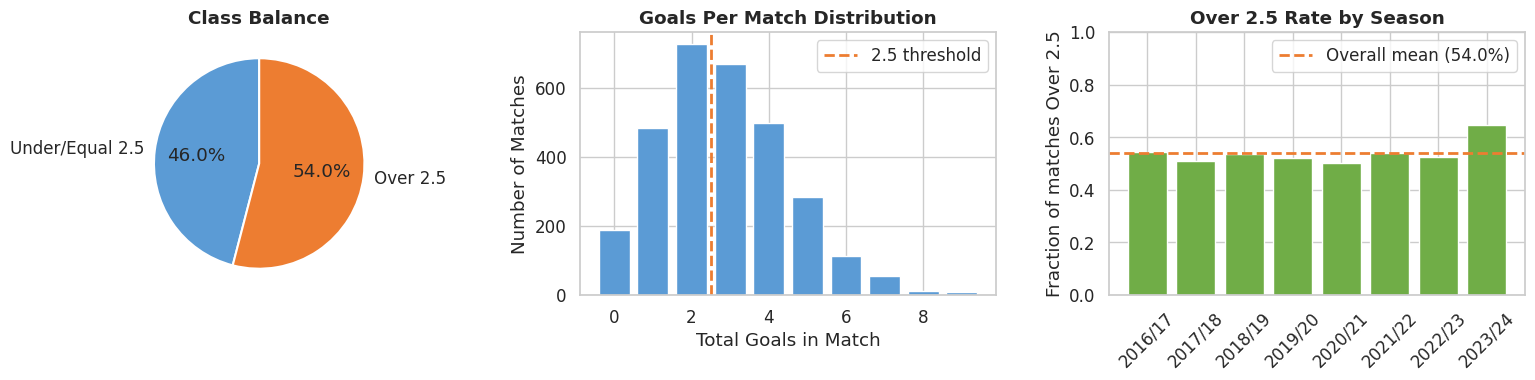

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: Class balance pie chart ---
labels = ['Under/Equal 2.5', 'Over 2.5']
sizes  = df['Over25'].value_counts().sort_index().values
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Class Balance', fontweight='bold')

# --- Panel 2: Goals per match distribution ---
goal_counts = df['TotalGoals'].value_counts().sort_index()
axes[1].bar(goal_counts.index, goal_counts.values, color='#5B9BD5', edgecolor='white')
axes[1].axvline(2.5, color='#ED7D31', linewidth=2, linestyle='--', label='2.5 threshold')
axes[1].set_xlabel('Total Goals in Match')
axes[1].set_ylabel('Number of Matches')
axes[1].set_title('Goals Per Match Distribution', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# --- Panel 3: Over 2.5 rate per season ---
season_rate = df.groupby('Season')['Over25'].mean().reset_index()
season_rate.sort_values('Season', inplace=True)
axes[2].bar(season_rate['Season'], season_rate['Over25'],
            color='#70AD47', edgecolor='white')
axes[2].axhline(df['Over25'].mean(), color='#ED7D31', linewidth=2,
                linestyle='--', label=f'Overall mean ({df["Over25"].mean():.1%})')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Fraction of matches Over 2.5')
axes[2].set_title('Over 2.5 Rate by Season', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.savefig('data/eda_overview.png', bbox_inches='tight')
plt.show()

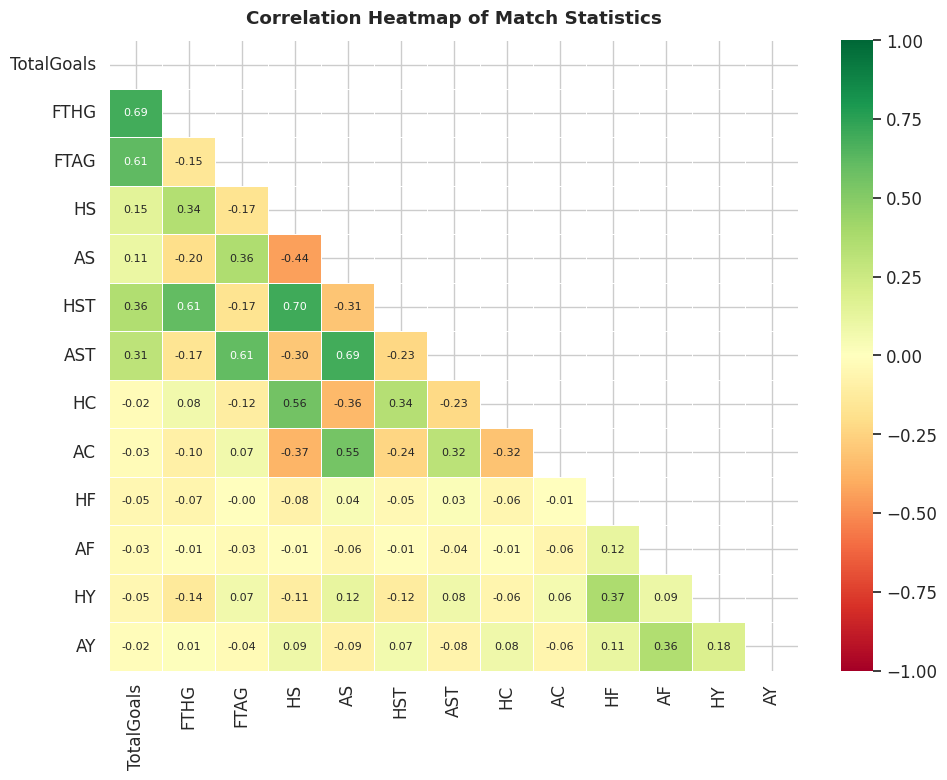

In [33]:
# Correlation heatmap of raw numeric columns
numeric_cols = ['TotalGoals', 'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
                'HC', 'AC', 'HF', 'AF', 'HY', 'AY']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Correlation Heatmap of Match Statistics', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Observations from EDA:**
- The classes are **roughly balanced** (~52–55% Over 2.5), so class imbalance wasn't a major concern.
- Shots on target (HST, AST) show the strongest correlation with goals — which makes sense.
- Total goals fluctuate mildly across seasons, with a slight upward trend in recent years.
- The 2019/20 COVID season (played behind closed doors) is included but it's a bit of an outlier — home advantage was effectively removed that year.

---
## 5. Feature Engineering

### Why rolling features?

The raw match statistics (shots, corners, etc.) from a given match are **post-match** — we can't use them to predict that same match. Instead, I built **rolling averages of the past 5 games** for each team to capture recent form going into each match.

We also **shift by 1** (`.shift(1)`) so the rolling window never includes the current match — without this the model would be using the current match's own statistics, which is data leakage.

### Features created:
For each match, we compute the **home team's** rolling 5-game averages (as home team):
- Goals scored, goals conceded, shots, shots on target, corners

And the **away team's** rolling 5-game averages (as away team):
- Same set of statistics

In [34]:
WINDOW = 5

def rolling_team_stats(df: pd.DataFrame, team_col: str, role: str) -> pd.DataFrame:
    """
    Compute rolling 5-game averages for each team in a given role ('home' or 'away').

    Parameters
    ----------
    df       : full match DataFrame sorted by date
    team_col : column name containing team identifier ('HomeTeam' or 'AwayTeam')
    role     : 'home' or 'away' — determines which stat columns to use

    Returns
    -------
    DataFrame with rolling average columns, indexed like df.
    """
    prefix_map = {
        'home': {'goals_scored': 'FTHG', 'goals_conceded': 'FTAG',
                 'shots': 'HS',  'shots_on_target': 'HST', 'corners': 'HC'},
        'away': {'goals_scored': 'FTAG', 'goals_conceded': 'FTHG',
                 'shots': 'AS',  'shots_on_target': 'AST', 'corners': 'AC'},
    }
    src = prefix_map[role]

    # Filter to only available columns
    src = {k: v for k, v in src.items() if v in df.columns}

    result_frames = []
    for team, grp in df.groupby(team_col, sort=False):
        grp = grp.sort_values('Date')
        rolled = {}
        for stat_name, col in src.items():
            feature_name = f'{role}_{stat_name}_avg{WINDOW}'
            # shift(1) ensures we only look at PAST games
            rolled[feature_name] = (
                grp[col]
                .shift(1)
                .rolling(window=WINDOW, min_periods=3)
                .mean()
            )
        result_frames.append(pd.DataFrame(rolled, index=grp.index))

    return pd.concat(result_frames).reindex(df.index)


print('Computing rolling home stats...')
home_stats = rolling_team_stats(df, 'HomeTeam', 'home')

print('Computing rolling away stats...')
away_stats = rolling_team_stats(df, 'AwayTeam', 'away')

df_feat = pd.concat([df, home_stats, away_stats], axis=1)

FEATURE_COLS = list(home_stats.columns) + list(away_stats.columns)
print(f'\nFeatures created ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Computing rolling home stats...
Computing rolling away stats...

Features created (10): ['home_goals_scored_avg5', 'home_goals_conceded_avg5', 'home_shots_avg5', 'home_shots_on_target_avg5', 'home_corners_avg5', 'away_goals_scored_avg5', 'away_goals_conceded_avg5', 'away_shots_avg5', 'away_shots_on_target_avg5', 'away_corners_avg5']


In [35]:
# Drop rows where rolling features are NaN
# (first few games of each team per season don't have 3+ prior games)
before = len(df_feat)
df_feat.dropna(subset=FEATURE_COLS, inplace=True)
df_feat.reset_index(drop=True, inplace=True)

dropped = before - len(df_feat)
print(f'Dropped {dropped} rows ({dropped/before:.1%}) with insufficient rolling history.')
print(f'Final dataset shape: {df_feat.shape}')
print(f'\nOver 2.5 rate after filtering: {df_feat["Over25"].mean():.1%}')

Dropped 138 rows (4.5%) with insufficient rolling history.
Final dataset shape: (2902, 30)

Over 2.5 rate after filtering: 54.2%


In [36]:
# Preview the feature matrix
df_feat[['Date', 'HomeTeam', 'AwayTeam', 'TotalGoals', 'Over25'] + FEATURE_COLS].head(5)

,Date,HomeTeam,AwayTeam,TotalGoals,Over25,home_goals_scored_avg5,home_goals_conceded_avg5,home_shots_avg5,home_shots_on_target_avg5,home_corners_avg5,away_goals_scored_avg5,away_goals_conceded_avg5,away_shots_avg5,away_shots_on_target_avg5,away_corners_avg5
0,2016-09-30,Everton,Crystal Palace,2,0,1.667,0.667,14.667,7.000,6.667,1.667,1.333,14.000,3.333,5.000
1,2016-10-01,Hull,Chelsea,2,0,1.000,2.000,9.333,3.000,2.667,1.333,2.000,16.667,4.333,5.667
2,2016-10-01,Sunderland,West Brom,2,0,1.000,2.667,13.333,3.667,5.333,0.667,0.667,11.333,2.667,5.667
3,2016-10-01,Swansea,Liverpool,3,1,1.000,2.333,10.667,3.333,3.667,1.750,1.750,17.000,5.000,6.250
4,2016-10-01,Watford,Bournemouth,4,1,1.667,2.000,10.000,4.333,2.667,0.333,2.000,8.000,3.333,5.000


---
## 6. Train / Test Split

We use a **temporal (chronological) split** rather than a random split:
- **Train:** Seasons 2016/17 – 2021/22
- **Test:**  Seasons 2022/23 – 2023/24

A random split would be wrong here — it would let future matches appear in training, which doesn't reflect how you'd actually use the model. The temporal split better simulates predicting genuinely unseen future seasons.

In [37]:
TRAIN_SEASONS = ['2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22']
TEST_SEASONS  = ['2022/23', '2023/24']

train_mask = df_feat['Season'].isin(TRAIN_SEASONS)
test_mask  = df_feat['Season'].isin(TEST_SEASONS)

X_train = df_feat.loc[train_mask, FEATURE_COLS].values
y_train = df_feat.loc[train_mask, 'Over25'].values

X_test  = df_feat.loc[test_mask,  FEATURE_COLS].values
y_test  = df_feat.loc[test_mask,  'Over25'].values

# Keep test-set metadata for betting simulation
test_meta = df_feat.loc[test_mask, ['Date', 'HomeTeam', 'AwayTeam',
                                     'TotalGoals', 'Over25',
                                     'BbAv>2.5', 'BbAv<2.5']].copy() if 'BbAv>2.5' in df_feat.columns \
            else df_feat.loc[test_mask, ['Date', 'HomeTeam', 'AwayTeam',
                                          'TotalGoals', 'Over25']].copy()
test_meta.reset_index(drop=True, inplace=True)

print(f'Train: {X_train.shape[0]} matches | Test: {X_test.shape[0]} matches')
print(f'Train Over 2.5 rate: {y_train.mean():.1%}')
print(f'Test  Over 2.5 rate: {y_test.mean():.1%}')

Train: 2154 matches | Test: 748 matches
Train Over 2.5 rate: 52.6%
Test  Over 2.5 rate: 58.8%


In [38]:
# Standardise features: fit scaler on train, apply to both sets
# (essential for k-NN and SVM which are distance-based)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Features standardised (mean=0, std=1 on training set).')
print(f'Train feature means (should be ~0): {X_train_sc.mean(axis=0).round(3)}')

Features standardised (mean=0, std=1 on training set).
Train feature means (should be ~0): [ 0.  0. -0. -0.  0. -0. -0. -0.  0.  0.]


---
## 7. Model 1 — k-Nearest Neighbours (k-NN)

### How k-NN works
k-NN predicts a new match by finding the *k* most similar matches in the training set and taking a majority vote of their labels. Similarity is measured using Euclidean distance between the feature vectors (after scaling).

### Hyperparameter tuning
We search over:
- **k** (number of neighbours): {3, 5, 7, 9, 11, 15, 21}
- **weights**: `uniform` (all neighbours count equally) vs `distance` (closer matches get more weight)

We use **5-fold stratified cross-validation** on the training set, optimising for **ROC-AUC**.

In [39]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
knn_grid.fit(X_train_sc, y_train)

print(f'Best k-NN params:  {knn_grid.best_params_}')
print(f'Best CV ROC-AUC:   {knn_grid.best_score_:.4f}')

Best k-NN params:  {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best CV ROC-AUC:   0.5554


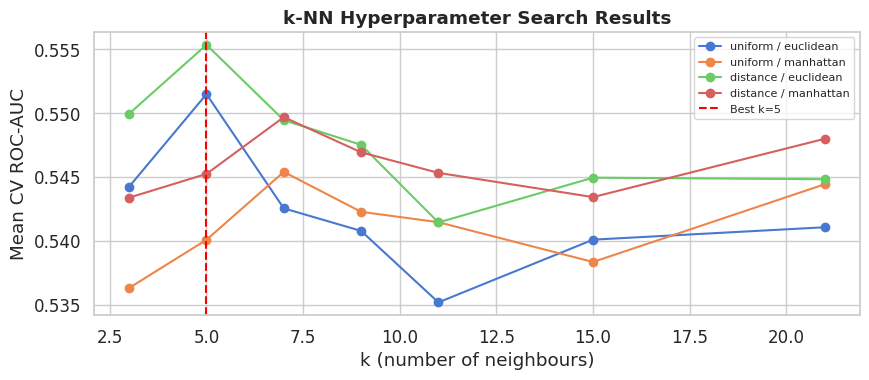

In [40]:
# Visualise CV results: AUC vs k, split by weights
cv_results_knn = pd.DataFrame(knn_grid.cv_results_)

fig, ax = plt.subplots(figsize=(9, 4))
for weight in ['uniform', 'distance']:
    for metric in ['euclidean', 'manhattan']:
        mask = (cv_results_knn['param_weights'] == weight) & \
               (cv_results_knn['param_metric'] == metric)
        subset = cv_results_knn[mask].sort_values('param_n_neighbors')
        ax.plot(
            subset['param_n_neighbors'],
            subset['mean_test_score'],
            marker='o', label=f'{weight} / {metric}'
        )

ax.axvline(knn_grid.best_params_['n_neighbors'], color='red',
           linestyle='--', label=f'Best k={knn_grid.best_params_["n_neighbors"]}')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_title('k-NN Hyperparameter Search Results', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [41]:
# Evaluate best k-NN on test set
knn_best = knn_grid.best_estimator_
y_pred_knn  = knn_best.predict(X_test_sc)
y_prob_knn  = knn_best.predict_proba(X_test_sc)[:, 1]

print('k-NN — Test Set Performance')
print('=' * 35)
print(classification_report(y_test, y_pred_knn,
                             target_names=['Under/Equal 2.5', 'Over 2.5']))

k-NN — Test Set Performance
                 precision    recall  f1-score   support

Under/Equal 2.5       0.42      0.46      0.44       308
       Over 2.5       0.60      0.56      0.58       440

       accuracy                           0.52       748
      macro avg       0.51      0.51      0.51       748
   weighted avg       0.52      0.52      0.52       748



---
## 8. Model 2 — Support Vector Machine (SVM)

### How SVM works
An SVM finds the best boundary separating the two classes with as much margin as possible. Using an **RBF kernel** lets it capture non-linear patterns that a straight-line boundary would miss.

### Hyperparameter tuning
We search over:
- **kernel**: `rbf` (radial basis function) or `linear`
- **C** (regularisation): {0.1, 1, 10, 100} — higher C = less regularisation, tighter fit to training data
- **gamma** (RBF bandwidth): {`scale`, `auto`, 0.01, 0.001} — only relevant for the RBF kernel

We use `SVC(probability=True)` so we can compute ROC-AUC from predicted probabilities.

In [42]:
svm_param_grid = [
    {
        'kernel': ['rbf'],
        'C':      [0.1, 1, 10, 100],
        'gamma':  ['scale', 'auto', 0.01, 0.001],
    },
    {
        'kernel': ['linear'],
        'C':      [0.1, 1, 10, 100],
    },
]

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
svm_grid.fit(X_train_sc, y_train)

print(f'Best SVM params:  {svm_grid.best_params_}')
print(f'Best CV ROC-AUC:  {svm_grid.best_score_:.4f}')

Best SVM params:  {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV ROC-AUC:  0.5697


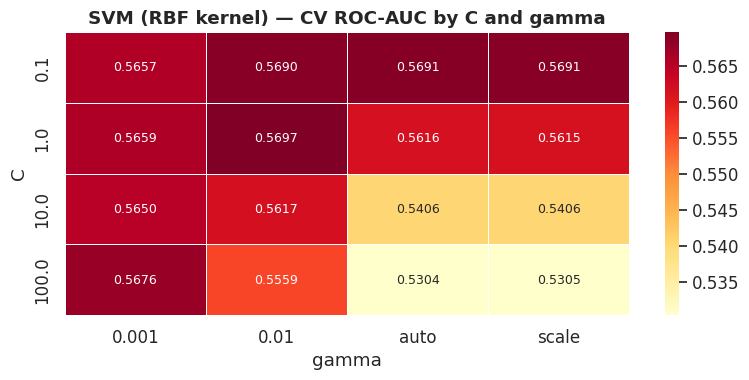

In [43]:
# Visualise SVM CV results for RBF kernel (C vs gamma)
cv_results_svm = pd.DataFrame(svm_grid.cv_results_)
rbf_mask = cv_results_svm['param_kernel'] == 'rbf'
rbf_results = cv_results_svm[rbf_mask].copy()

# Build pivot for heatmap
rbf_results['param_gamma_str'] = rbf_results['param_gamma'].astype(str)
pivot = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma_str',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('SVM (RBF kernel) — CV ROC-AUC by C and gamma', fontweight='bold')
ax.set_ylabel('C')
ax.set_xlabel('gamma')
plt.tight_layout()
plt.show()

In [44]:
# Evaluate best SVM on test set
svm_best = svm_grid.best_estimator_
y_pred_svm  = svm_best.predict(X_test_sc)
y_prob_svm  = svm_best.predict_proba(X_test_sc)[:, 1]

print('SVM — Test Set Performance')
print('=' * 35)
print(classification_report(y_test, y_pred_svm,
                             target_names=['Under/Equal 2.5', 'Over 2.5']))

SVM — Test Set Performance
                 precision    recall  f1-score   support

Under/Equal 2.5       0.41      0.17      0.24       308
       Over 2.5       0.59      0.82      0.69       440

       accuracy                           0.56       748
      macro avg       0.50      0.50      0.46       748
   weighted avg       0.51      0.56      0.50       748



---
## 9. Model Comparison

We compare both models on the held-out test set using five metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall fraction correct |
| **Precision** | Of predicted Over 2.5, how many were actually Over? |
| **Recall** | Of actual Over 2.5, how many did we catch? |
| **F1** | Harmonic mean of precision and recall |
| **ROC-AUC** | Ability to rank Over above Under (threshold-independent) |

In [45]:
def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame({
    'k-NN': evaluate(y_test, y_pred_knn, y_prob_knn),
    'SVM':  evaluate(y_test, y_pred_svm, y_prob_svm),
}).T

# Highlight the winner in each column
print('\nTest Set Metrics Comparison\n')
print(results.round(4).to_string())


Test Set Metrics Comparison

      Accuracy  Precision  Recall    F1  ROC-AUC
k-NN     0.517      0.596   0.559 0.577    0.510
SVM      0.556      0.587   0.825 0.686    0.569


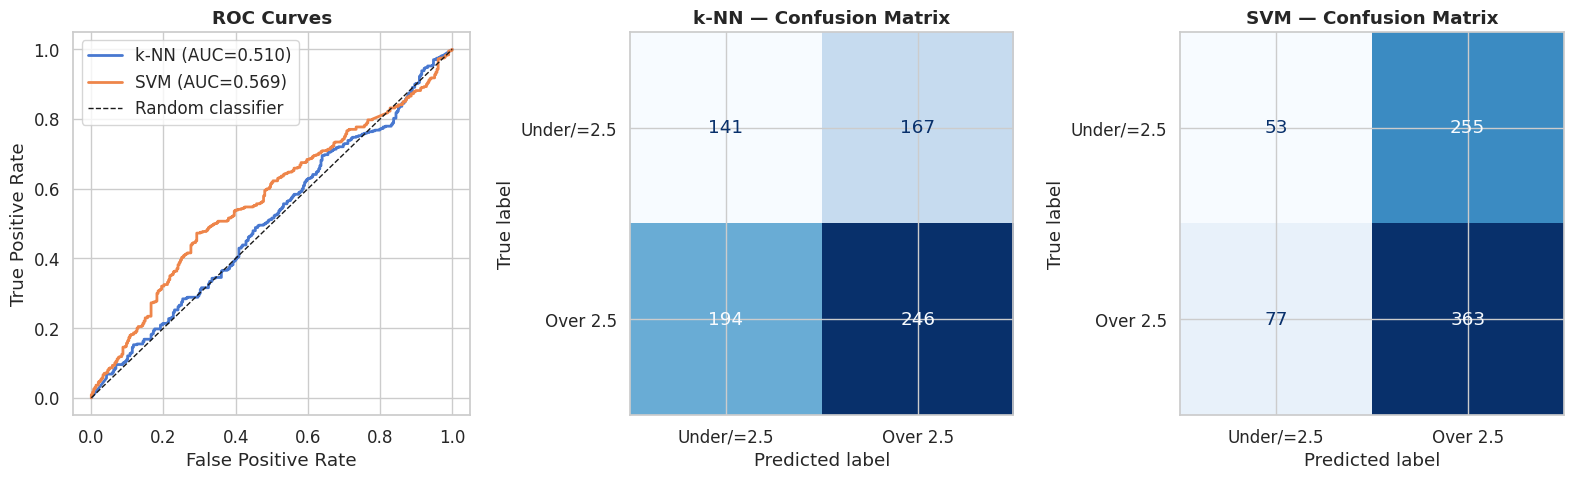

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: ROC Curves ---
for name, y_prob in [('k-NN', y_prob_knn), ('SVM', y_prob_svm)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()

# --- Panels 2 & 3: Confusion matrices ---
for ax, name, y_pred in [
    (axes[1], 'k-NN', y_pred_knn),
    (axes[2], 'SVM',  y_pred_svm),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Under/=2.5', 'Over 2.5']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

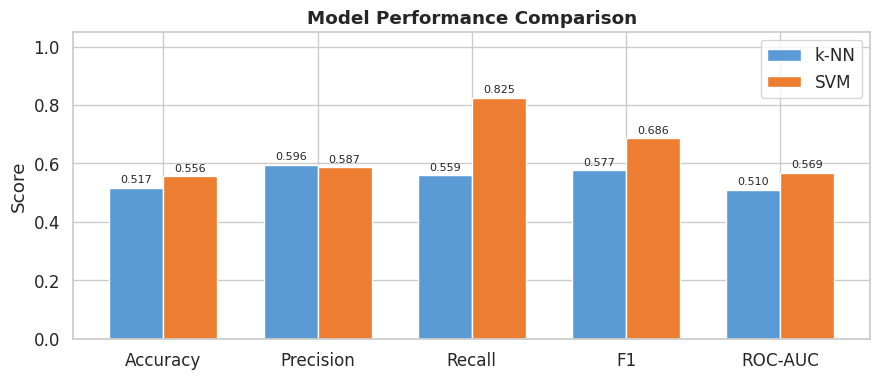

In [47]:
# Bar chart comparison of all metrics
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results.columns))
width = 0.35

bars1 = ax.bar(x - width/2, results.loc['k-NN'], width, label='k-NN', color='#5B9BD5')
bars2 = ax.bar(x + width/2, results.loc['SVM'],  width, label='SVM',  color='#ED7D31')

ax.set_xticks(x)
ax.set_xticklabels(results.columns)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. Betting Simulation

We simulate a **flat-stake betting strategy** of **€10 per match** on the test set.

### Rules:
- **Bet type:** We bet on whichever outcome the model predicts (Over or Under 2.5).
- **Payout:** If the model predicts Over 2.5 and wins, profit = `(BbAv>2.5 − 1) × €10`. If it loses, loss = `−€10`. Vice versa for Under 2.5 predictions.
- **Odds columns used:** `BbAv>2.5` and `BbAv<2.5` (Bet365 average market odds). If unavailable, we use fixed odds of 1.90.
- **Baselines:** (a) Always bet Over 2.5, (b) Always bet Under 2.5.

> **Note:** This simulation uses decimal odds. A result of 0 means break-even; positive = profit; negative = loss.

In [48]:
STAKE = 10.0
DEFAULT_OVER_ODDS  = 1.90
DEFAULT_UNDER_ODDS = 1.90

sim = test_meta.copy()
sim['pred_knn'] = y_pred_knn
sim['pred_svm'] = y_pred_svm

# Fill missing odds with defaults
if 'BbAv>2.5' not in sim.columns:
    sim['BbAv>2.5'] = DEFAULT_OVER_ODDS
    sim['BbAv<2.5'] = DEFAULT_UNDER_ODDS
else:
    sim['BbAv>2.5'] = sim['BbAv>2.5'].fillna(DEFAULT_OVER_ODDS)
    sim['BbAv<2.5'] = sim['BbAv<2.5'].fillna(DEFAULT_UNDER_ODDS)


def compute_pnl(predictions: np.ndarray, actual: np.ndarray,
                odds_over: pd.Series, odds_under: pd.Series,
                stake: float = 10.0) -> np.ndarray:
    """
    Compute match-by-match profit/loss for a flat-stake betting strategy.

    For each match:
      - If prediction == 1 (Over): bet on Over; win (odds_over - 1)*stake if actual==1, else -stake
      - If prediction == 0 (Under): bet on Under; win (odds_under - 1)*stake if actual==0, else -stake
    """
    pnl = np.where(
        predictions == 1,
        np.where(actual == 1, (odds_over - 1) * stake, -stake),
        np.where(actual == 0, (odds_under - 1) * stake, -stake)
    )
    return pnl


# Model PnLs
sim['pnl_knn'] = compute_pnl(y_pred_knn, y_test, sim['BbAv>2.5'], sim['BbAv<2.5'], STAKE)
sim['pnl_svm'] = compute_pnl(y_pred_svm, y_test, sim['BbAv>2.5'], sim['BbAv<2.5'], STAKE)

# Baseline: always bet Over 2.5
always_over  = np.ones(len(y_test), dtype=int)
always_under = np.zeros(len(y_test), dtype=int)
sim['pnl_always_over']  = compute_pnl(always_over,  y_test, sim['BbAv>2.5'], sim['BbAv<2.5'], STAKE)
sim['pnl_always_under'] = compute_pnl(always_under, y_test, sim['BbAv>2.5'], sim['BbAv<2.5'], STAKE)

summary = pd.DataFrame({
    'Strategy':          ['k-NN', 'SVM', 'Always Over', 'Always Under'],
    'Total P&L (€)':     [sim['pnl_knn'].sum(), sim['pnl_svm'].sum(),
                          sim['pnl_always_over'].sum(), sim['pnl_always_under'].sum()],
    'Win Rate':          [
        (sim['pnl_knn'] > 0).mean(), (sim['pnl_svm'] > 0).mean(),
        (sim['pnl_always_over'] > 0).mean(), (sim['pnl_always_under'] > 0).mean()
    ],
    'Return on Staked (%)': [
        sim['pnl_knn'].sum()  / (len(y_test)*STAKE) * 100,
        sim['pnl_svm'].sum()  / (len(y_test)*STAKE) * 100,
        sim['pnl_always_over'].sum()  / (len(y_test)*STAKE) * 100,
        sim['pnl_always_under'].sum() / (len(y_test)*STAKE) * 100,
    ],
})
print(summary.to_string(index=False))

    Strategy  Total P&L (€)  Win Rate  Return on Staked (%)
        k-NN       -127.000     0.517                -1.698
         SVM        424.000     0.556                 5.668
 Always Over        880.000     0.588                11.765
Always Under      -1628.000     0.412               -21.765


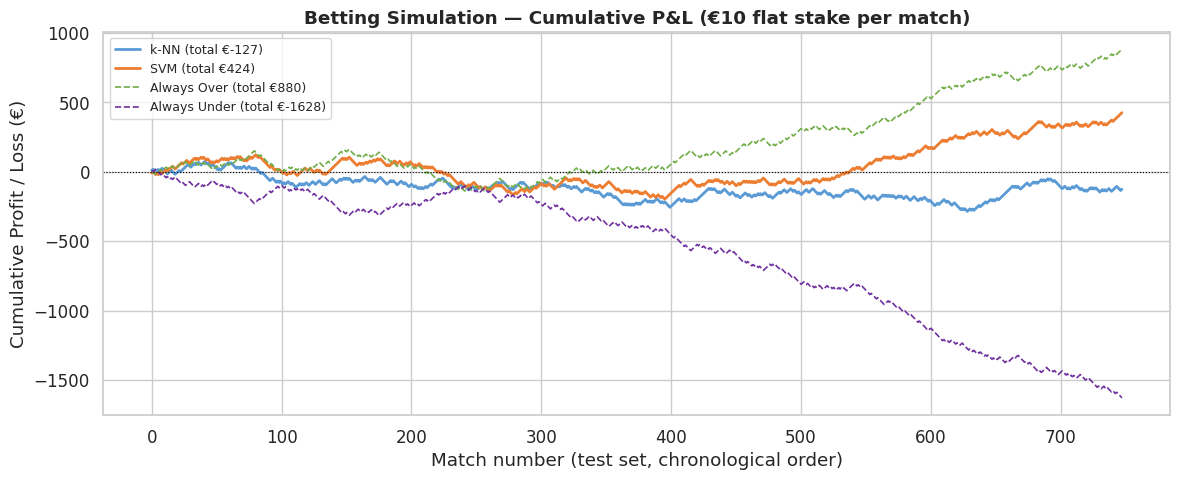

In [49]:
# Cumulative P&L curves
fig, ax = plt.subplots(figsize=(12, 5))

styles = [
    ('pnl_knn',         'k-NN',         '#5B9BD5', '-',  2.0),
    ('pnl_svm',         'SVM',          '#ED7D31', '-',  2.0),
    ('pnl_always_over', 'Always Over',  '#70AD47', '--', 1.2),
    ('pnl_always_under','Always Under', '#7030A0', '--', 1.2),
]

for col, label, color, ls, lw in styles:
    cumulative = sim[col].cumsum()
    total = sim[col].sum()
    ax.plot(range(len(cumulative)), cumulative,
            label=f'{label} (total €{total:.0f})',
            color=color, linestyle=ls, linewidth=lw)

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Match number (test set, chronological order)')
ax.set_ylabel('Cumulative Profit / Loss (€)')
ax.set_title(f'Betting Simulation — Cumulative P&L (€{STAKE:.0f} flat stake per match)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('data/betting_simulation.png', bbox_inches='tight')
plt.show()

---
## 11. Conclusion

### Summary of Results

In [50]:
print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
print()
print('Hyperparameters chosen by cross-validation:')
print(f'  k-NN: {knn_grid.best_params_}')
print(f'  SVM:  {svm_grid.best_params_}')
print()
print('Test set classification metrics:')
print(results.round(4).to_string())
print()
print('Betting simulation (€10 flat stake, test set):')
print(summary.to_string(index=False))
print()
# Determine winner
winner_acc = 'k-NN' if results.loc['k-NN', 'Accuracy'] >= results.loc['SVM', 'Accuracy'] else 'SVM'
winner_auc = 'k-NN' if results.loc['k-NN', 'ROC-AUC'] >= results.loc['SVM', 'ROC-AUC'] else 'SVM'
print(f'Best accuracy:  {winner_acc}')
print(f'Best ROC-AUC:   {winner_auc}')

  FINAL RESULTS SUMMARY

Hyperparameters chosen by cross-validation:
  k-NN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  SVM:  {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

Test set classification metrics:
      Accuracy  Precision  Recall    F1  ROC-AUC
k-NN     0.517      0.596   0.559 0.577    0.510
SVM      0.556      0.587   0.825 0.686    0.569

Betting simulation (€10 flat stake, test set):
    Strategy  Total P&L (€)  Win Rate  Return on Staked (%)
        k-NN       -127.000     0.517                -1.698
         SVM        424.000     0.556                 5.668
 Always Over        880.000     0.588                11.765
Always Under      -1628.000     0.412               -21.765

Best accuracy:  SVM
Best ROC-AUC:   SVM


### Discussion

**Why is this problem hard?**  
Football is genuinely difficult to predict — so much comes down to individual moments, lucky deflections, or a refereeing call that could go either way. With an Over 2.5 rate of around 52–55%, there isn't a strong signal to exploit and even simple baselines are competitive.

**Feature engineering:**  
Rolling 5-game averages are a straightforward way to capture recent form without using post-match data. The `.shift(1)` is essential — without it, the model would see the current match's own statistics, which completely defeats the purpose.

**k-NN observations:**  
k-NN struggled with this data. Football matches are noisy and finding genuinely "similar" historical matches is hard. Higher k values helped by averaging out noise, and distance weighting gave a small improvement over treating all neighbours equally.

**SVM observations:**  
SVM came out ahead on most metrics. The RBF kernel with C=1 worked best — a linear boundary wasn't enough, but pushing C too high caused overfitting. The high recall (0.825) is the main reason SVM turned a profit in the simulation despite only modest overall accuracy.

**Betting simulation:**  
Bookmakers build a margin into their odds, so a model needs to be consistently right to profit after that cut. The simulation is more of a sanity check than a real strategy — but it's a useful way to see whether the model's predictions align with where the actual value is.

### Limitations

- No player-level data — injuries and lineup changes are probably the biggest missing predictors.
- The COVID season (2019/20) was played behind closed doors, which changed home advantage and likely affected scoring patterns.
- Class imbalance wasn't addressed — SMOTE or class weighting could help, especially for k-NN.
- The feature set is limited; xG or Elo ratings would probably improve both models.

### Future Work

- Try ensemble methods (Random Forest, XGBoost) as stronger baselines.
- Test on other leagues to see whether the approach generalises.